Original image shape: (512, 512)


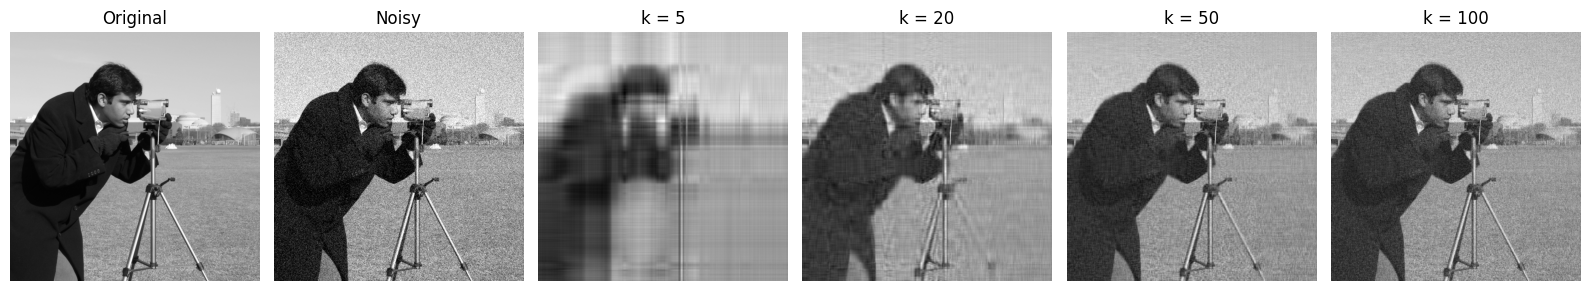

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, img_as_float # pip install scikit-image
from skimage.util import random_noise

# Step 1: Load grayscale image
original = img_as_float(data.camera())  # Grayscale image of a man holding a camera
print("Original image shape:", original.shape)

# Step 2: Add Gaussian noise
noisy_image = random_noise(original, mode='gaussian', var=0.01)

# Step 3: Perform SVD on the noisy image
U, S, VT = np.linalg.svd(noisy_image, full_matrices=False)

# Step 4: Function to reconstruct image using top k singular values
def svd_denoise(U, S, VT, k):
    S_k = np.diag(S[:k])
    U_k = U[:, :k]
    VT_k = VT[:k, :]
    return np.dot(U_k, np.dot(S_k, VT_k))

# Step 5: Reconstruct with different levels of approximation
ks = [5, 20, 50, 100]  # Try different k values
reconstructed_images = [svd_denoise(U, S, VT, k) for k in ks]

# Step 6: Plot original, noisy, and denoised versions
fig, axes = plt.subplots(1, len(ks) + 2, figsize=(16, 5))
axes[0].imshow(original, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(noisy_image, cmap='gray')
axes[1].set_title("Noisy")
axes[1].axis('off')

for i, k in enumerate(ks):
    axes[i + 2].imshow(reconstructed_images[i], cmap='gray')
    axes[i + 2].set_title(f"k = {k}")
    axes[i + 2].axis('off')

plt.tight_layout()
plt.show()


## observation
Noisy Image: Has random variation due to added Gaussian noise.

Denoised Images:
- Low k (e.g., 5): Removes a lot of detail along with noise (blurry).
- Medium k (e.g., 50): Good trade-off — keeps main structure and removes much of the noise.
- High k (e.g., 100+): Looks closer to noisy image — more details, but also more noise.